# Cost & Financial Analysis
**Notebook 05 | Phase 6 — Focus Area: Cost & Financial**

This notebook provides deep financial analytics:
- **Cost distribution analysis** — Skewness, heavy-tail behavior, Pareto concentration
- **Payer deep dive** — Coverage rates, denied claims, payer mix optimization
- **Patient financial burden** — Out-of-pocket analysis, catastrophic cost identification
- **Cost drivers** — What drives high-cost encounters? Regression-based factor analysis
- **Medication economics** — Drug costs, polypharmacy cost impact, payer coverage gaps
- **Year-over-year trends** — Cost inflation, payer mix shifts, spending forecasts
- **Power BI-ready exports** — Financial summary tables saved to `data/processed/`


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, spearmanr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
COLORS = sns.color_palette('muted', 10)
HIGHLIGHT = '#e74c3c'

import os
for p in ['.', '..', '../..']:
    if os.path.exists(os.path.join(p, 'data/raw/patients.csv')):
        os.chdir(p); break

patients      = pd.read_csv('data/raw/patients.csv')
encounters    = pd.read_csv('data/raw/encounters.csv')
conditions    = pd.read_csv('data/raw/conditions.csv')
medications   = pd.read_csv('data/raw/medications.csv')
procedures    = pd.read_csv('data/raw/procedures.csv')
payers        = pd.read_csv('data/raw/payers.csv')
payer_trans   = pd.read_csv('data/raw/payer_transitions.csv')

patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'])
encounters['START']   = pd.to_datetime(encounters['START'], utc=True)
encounters['STOP']    = pd.to_datetime(encounters['STOP'], utc=True)
medications['START']  = pd.to_datetime(medications['START'])
medications['STOP']   = pd.to_datetime(medications['STOP'])

ref_date = pd.Timestamp('2020-04-01')
patients['AGE'] = patients.apply(
    lambda r: (r['DEATHDATE'] - r['BIRTHDATE']).days / 365.25
              if pd.notna(r['DEATHDATE'])
              else (ref_date - r['BIRTHDATE']).days / 365.25, axis=1).astype(int)
patients['AGE_GROUP'] = pd.cut(patients['AGE'],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=['0-17', '18-34', '35-49', '50-64', '65-79', '80+'])

encounters['OUT_OF_POCKET'] = encounters['TOTAL_CLAIM_COST'] - encounters['PAYER_COVERAGE']
encounters['YEAR'] = encounters['START'].dt.year
encounters['DURATION_HRS'] = (encounters['STOP'] - encounters['START']).dt.total_seconds() / 3600
encounters['LOS_DAYS'] = encounters['DURATION_HRS'] / 24

os.makedirs('data/processed', exist_ok=True)
print(f"Loaded: {len(encounters):,} encounters | Total billed: ${encounters['TOTAL_CLAIM_COST'].sum():,.0f}")


Loaded: 53,346 encounters | Total billed: $6,868,313


---
## 1. Cost Distribution & Concentration Analysis
Understanding the shape of healthcare spending — skewness, heavy tails, and Pareto concentration.


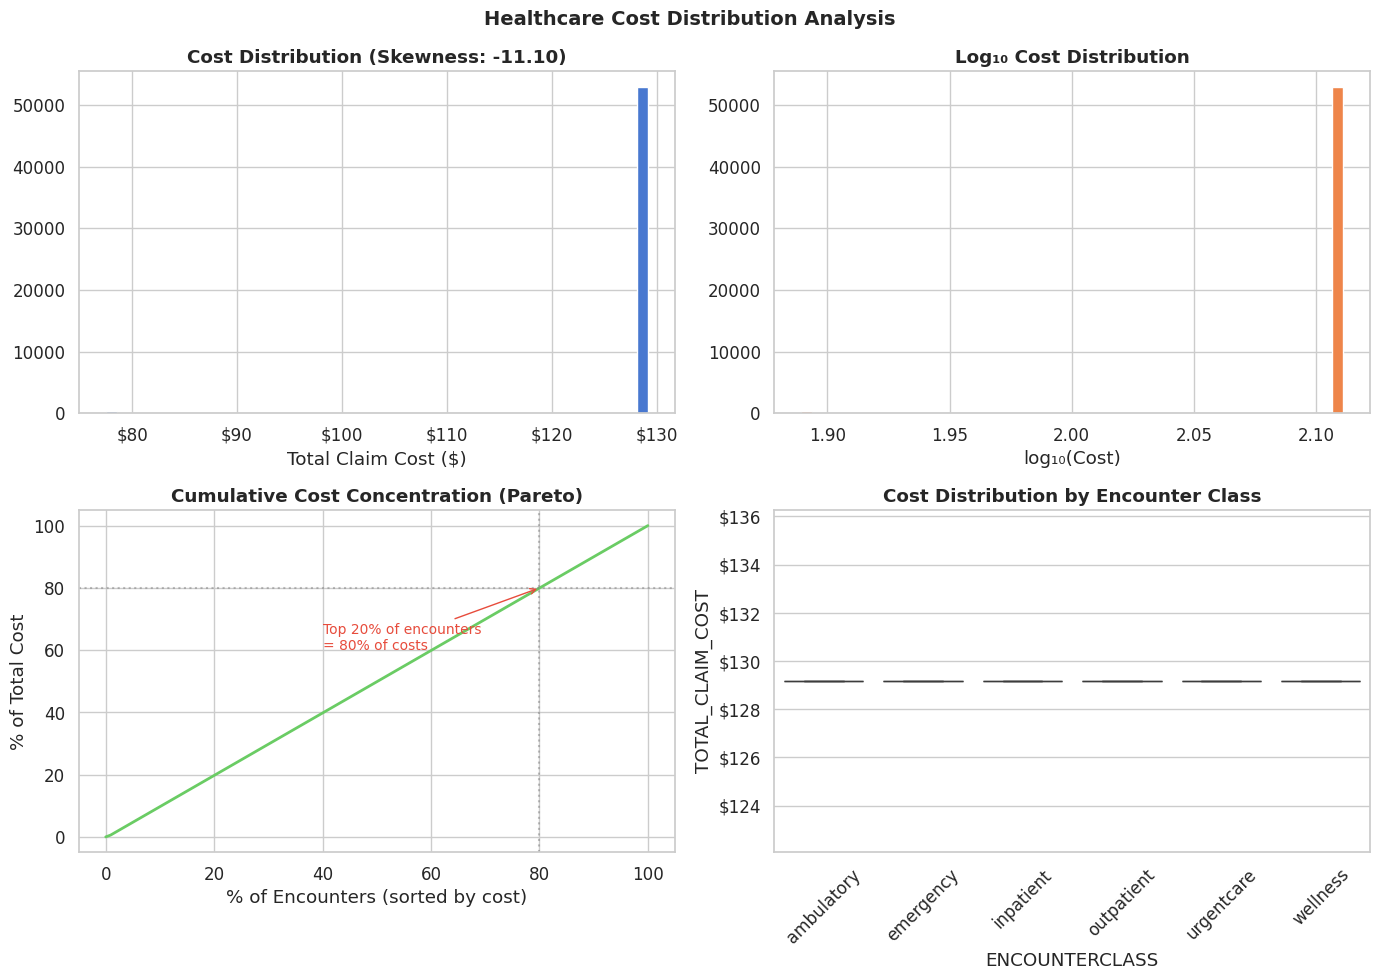

Cost stats: Mean=$128.75 | Median=$129.16 | Std=$4.58
Skewness: -11.10 | Kurtosis: 121.13
Top 5% of encounters account for 5.0% of total cost
Top 20% of encounters account for 20.1% of total cost


In [2]:
# 1.1 Cost distribution deep dive
costs = encounters['TOTAL_CLAIM_COST']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Raw distribution
axes[0,0].hist(costs[costs > 0], bins=50, color=COLORS[0], edgecolor='white')
axes[0,0].set_title(f'Cost Distribution (Skewness: {costs.skew():.2f})')
axes[0,0].set_xlabel('Total Claim Cost ($)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-transformed
axes[0,1].hist(np.log10(costs[costs > 0]), bins=50, color=COLORS[1], edgecolor='white')
axes[0,1].set_title('Log₁₀ Cost Distribution')
axes[0,1].set_xlabel('log₁₀(Cost)')

# Cumulative distribution
sorted_costs = np.sort(costs)
cumulative = np.cumsum(sorted_costs) / sorted_costs.sum() * 100
pct_patients = np.arange(1, len(sorted_costs) + 1) / len(sorted_costs) * 100
axes[1,0].plot(pct_patients, cumulative, color=COLORS[2], linewidth=2)
axes[1,0].axhline(80, color='gray', linestyle=':', alpha=0.5)
axes[1,0].axvline(80, color='gray', linestyle=':', alpha=0.5)
axes[1,0].set_title('Cumulative Cost Concentration (Pareto)')
axes[1,0].set_xlabel('% of Encounters (sorted by cost)')
axes[1,0].set_ylabel('% of Total Cost')
# Find what % of encounters account for 80% of cost
idx_80 = np.searchsorted(cumulative, 80)
pct_80 = 100 - pct_patients[idx_80]
axes[1,0].annotate(f'Top {pct_80:.0f}% of encounters\n= 80% of costs',
                   xy=(100-pct_80, 80), fontsize=10, color=HIGHLIGHT,
                   arrowprops=dict(arrowstyle='->', color=HIGHLIGHT),
                   xytext=(40, 60))

# Box plot by class
class_order = encounters.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST'].median().sort_values().index
sns.boxplot(data=encounters[encounters['TOTAL_CLAIM_COST'] > 0], x='ENCOUNTERCLASS',
            y='TOTAL_CLAIM_COST', order=class_order, ax=axes[1,1], palette='muted', showfliers=False)
axes[1,1].set_title('Cost Distribution by Encounter Class')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Healthcare Cost Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/45_cost_distribution_deep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cost stats: Mean=${costs.mean():,.2f} | Median=${costs.median():,.2f} | Std=${costs.std():,.2f}")
print(f"Skewness: {costs.skew():.2f} | Kurtosis: {costs.kurtosis():.2f}")
print(f"Top 5% of encounters account for {costs.nlargest(int(len(costs)*0.05)).sum()/costs.sum()*100:.1f}% of total cost")
print(f"Top 20% of encounters account for {costs.nlargest(int(len(costs)*0.20)).sum()/costs.sum()*100:.1f}% of total cost")


---
## 2. Payer Deep Dive
Coverage rates, payer mix, and performance comparison across payers.


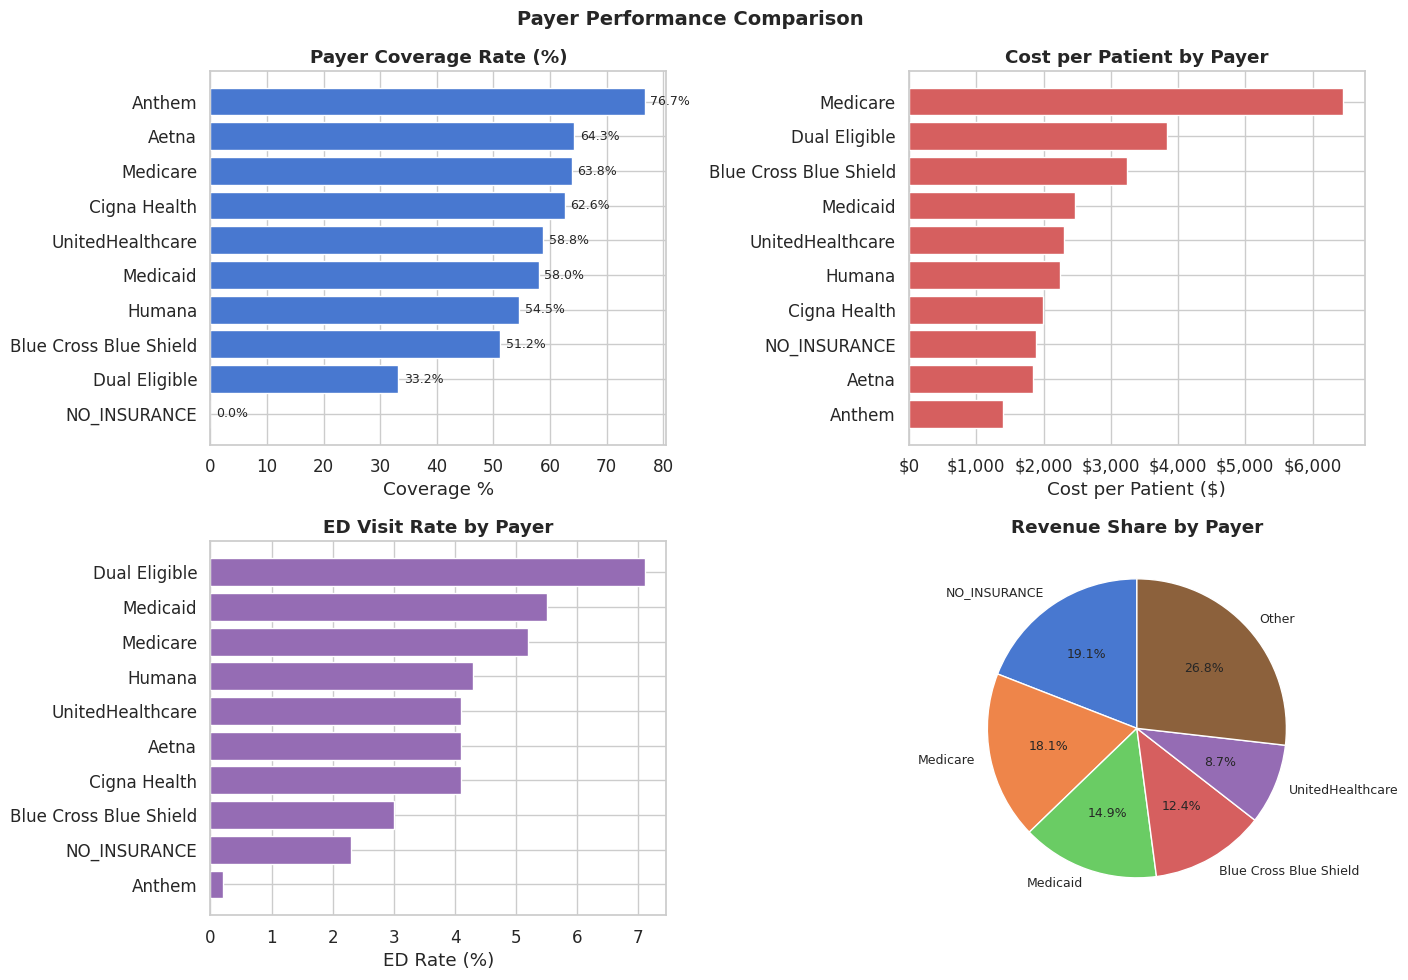

In [3]:
# 2.1 Detailed payer comparison
enc_payer = encounters.merge(payers[['Id', 'NAME']], left_on='PAYER', right_on='Id', suffixes=('', '_pyr'))

payer_detail = enc_payer.groupby('NAME').agg(
    encounters=('Id', 'count'),
    unique_patients=('PATIENT', 'nunique'),
    total_billed=('TOTAL_CLAIM_COST', 'sum'),
    total_covered=('PAYER_COVERAGE', 'sum'),
    avg_cost=('TOTAL_CLAIM_COST', 'mean'),
    median_cost=('TOTAL_CLAIM_COST', 'median'),
    avg_oop=('OUT_OF_POCKET', 'mean'),
    ed_visits=('ENCOUNTERCLASS', lambda x: (x == 'emergency').sum()),
    inpatient=('ENCOUNTERCLASS', lambda x: (x == 'inpatient').sum())
).reset_index()
payer_detail['coverage_rate'] = (payer_detail['total_covered'] / payer_detail['total_billed'] * 100).round(1)
payer_detail['ed_rate'] = (payer_detail['ed_visits'] / payer_detail['encounters'] * 100).round(1)
payer_detail['cost_per_patient'] = (payer_detail['total_billed'] / payer_detail['unique_patients']).round(0)
payer_detail = payer_detail.sort_values('total_billed', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Coverage rate comparison
payer_sorted = payer_detail.sort_values('coverage_rate')
colors = [HIGHLIGHT if v == 0 else COLORS[0] for v in payer_sorted['coverage_rate']]
axes[0,0].barh(payer_sorted['NAME'], payer_sorted['coverage_rate'], color=colors, edgecolor='white')
axes[0,0].set_title('Payer Coverage Rate (%)')
axes[0,0].set_xlabel('Coverage %')
for i, (_, row) in enumerate(payer_sorted.iterrows()):
    axes[0,0].text(row['coverage_rate'] + 1, i, f"{row['coverage_rate']:.1f}%", va='center', fontsize=9)

# Cost per patient by payer
payer_cpp = payer_detail.sort_values('cost_per_patient')
axes[0,1].barh(payer_cpp['NAME'], payer_cpp['cost_per_patient'], color=COLORS[3], edgecolor='white')
axes[0,1].set_title('Cost per Patient by Payer')
axes[0,1].set_xlabel('Cost per Patient ($)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ED rate by payer
payer_ed = payer_detail.sort_values('ed_rate')
axes[1,0].barh(payer_ed['NAME'], payer_ed['ed_rate'], color=COLORS[4], edgecolor='white')
axes[1,0].set_title('ED Visit Rate by Payer')
axes[1,0].set_xlabel('ED Rate (%)')

# Revenue composition pie (top 5 + other)
top5 = payer_detail.head(5)
other = pd.DataFrame([{'NAME': 'Other', 'total_billed': payer_detail.iloc[5:]['total_billed'].sum()}])
pie_data = pd.concat([top5[['NAME', 'total_billed']], other], ignore_index=True)
axes[1,1].pie(pie_data['total_billed'], labels=pie_data['NAME'], autopct='%1.1f%%',
              colors=COLORS[:6], startangle=90, textprops={'fontsize': 9})
axes[1,1].set_title('Revenue Share by Payer')

plt.suptitle('Payer Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/46_payer_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# 2.2 Payer performance summary table
print("=== Payer Performance Summary ===")
display_cols = ['NAME', 'encounters', 'unique_patients', 'total_billed', 'coverage_rate', 'cost_per_patient', 'ed_rate']
print(payer_detail[display_cols].to_string(index=False, float_format='${:,.0f}'.format))


=== Payer Performance Summary ===
                  NAME  encounters  unique_patients  total_billed  coverage_rate  cost_per_patient  ed_rate
          NO_INSURANCE       10175              693    $1,310,431             $0            $1,891       $2
              Medicare        9645              193    $1,245,645            $64            $6,454       $5
              Medicaid        7966              415    $1,021,810            $58            $2,462       $6
Blue Cross Blue Shield        6604              262      $850,699            $51            $3,247       $3
      UnitedHealthcare        4654              260      $598,630            $59            $2,302       $4
                Humana        4115              235      $526,843            $54            $2,242       $4
          Cigna Health        3766              244      $485,642            $63            $1,990       $4
                 Aetna        3433              240      $442,838            $64            $1,845    

---
## 3. Patient Financial Burden Analysis
Identifying patients with catastrophic costs and analyzing the out-of-pocket burden distribution.


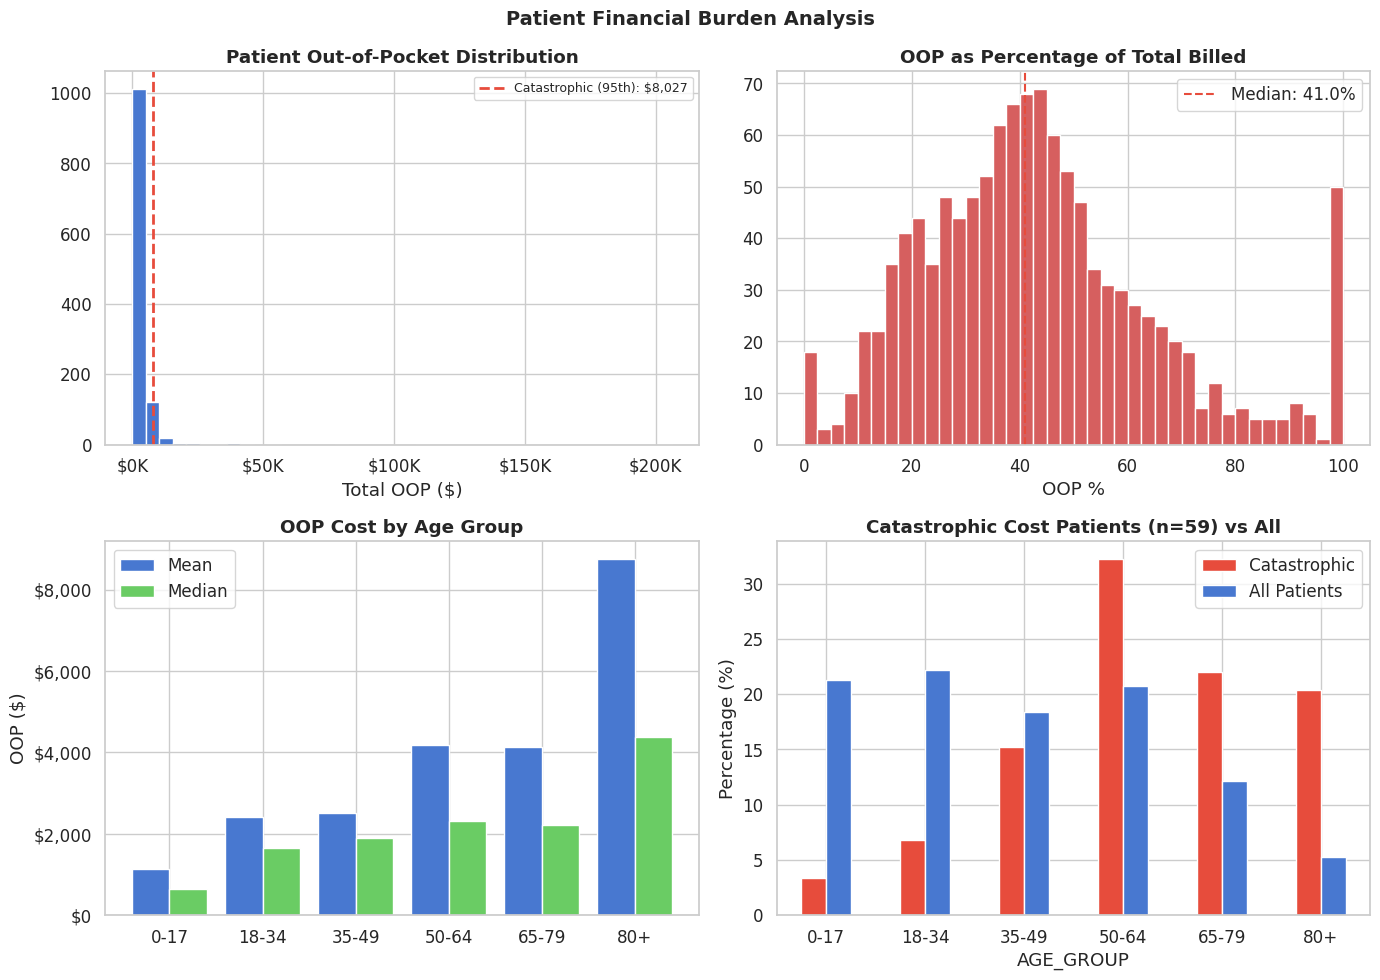

Catastrophic threshold (95th pctile): $8,027
Catastrophic patients: 59 (5.0%)
  Avg age: 63 | Avg encounters: 251


In [5]:
# 3.1 Patient-level financial summary
patient_finance = encounters.groupby('PATIENT').agg(
    total_billed=('TOTAL_CLAIM_COST', 'sum'),
    total_covered=('PAYER_COVERAGE', 'sum'),
    total_oop=('OUT_OF_POCKET', 'sum'),
    encounter_count=('Id', 'count'),
    ed_visits=('ENCOUNTERCLASS', lambda x: (x == 'emergency').sum()),
    inpatient_visits=('ENCOUNTERCLASS', lambda x: (x == 'inpatient').sum())
).reset_index()
patient_finance = patient_finance.merge(patients[['Id', 'AGE', 'AGE_GROUP', 'GENDER', 'RACE',
                                                    'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']],
                                         left_on='PATIENT', right_on='Id')
patient_finance['oop_pct'] = (patient_finance['total_oop'] / patient_finance['total_billed'] * 100).clip(0, 100)

# Catastrophic threshold: > 95th percentile of OOP
catastrophic_threshold = patient_finance['total_oop'].quantile(0.95)
patient_finance['IS_CATASTROPHIC'] = patient_finance['total_oop'] >= catastrophic_threshold

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# OOP distribution
axes[0,0].hist(patient_finance['total_oop'], bins=40, color=COLORS[0], edgecolor='white')
axes[0,0].axvline(catastrophic_threshold, color=HIGHLIGHT, linestyle='--', linewidth=2,
                  label=f'Catastrophic (95th): ${catastrophic_threshold:,.0f}')
axes[0,0].set_title('Patient Out-of-Pocket Distribution')
axes[0,0].set_xlabel('Total OOP ($)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0,0].legend(fontsize=9)

# OOP% distribution
axes[0,1].hist(patient_finance['oop_pct'], bins=40, color=COLORS[3], edgecolor='white')
axes[0,1].set_title('OOP as Percentage of Total Billed')
axes[0,1].set_xlabel('OOP %')
axes[0,1].axvline(patient_finance['oop_pct'].median(), color=HIGHLIGHT, linestyle='--',
                  label=f"Median: {patient_finance['oop_pct'].median():.1f}%")
axes[0,1].legend()

# OOP by age group
oop_age = patient_finance.groupby('AGE_GROUP')['total_oop'].agg(['mean', 'median'])
x = np.arange(len(oop_age))
axes[1,0].bar(x - 0.2, oop_age['mean'], 0.4, label='Mean', color=COLORS[0], edgecolor='white')
axes[1,0].bar(x + 0.2, oop_age['median'], 0.4, label='Median', color=COLORS[2], edgecolor='white')
axes[1,0].set_title('OOP Cost by Age Group')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(oop_age.index.astype(str))
axes[1,0].set_ylabel('OOP ($)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1,0].legend()

# Catastrophic cost patients profile
cat = patient_finance[patient_finance['IS_CATASTROPHIC']]
cat_age = cat['AGE_GROUP'].value_counts(normalize=True) * 100
all_age = patient_finance['AGE_GROUP'].value_counts(normalize=True) * 100
compare = pd.DataFrame({'Catastrophic': cat_age, 'All Patients': all_age}).fillna(0)
compare.plot(kind='bar', ax=axes[1,1], color=[HIGHLIGHT, COLORS[0]], edgecolor='white')
axes[1,1].set_title(f'Catastrophic Cost Patients (n={len(cat)}) vs All')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Patient Financial Burden Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/47_financial_burden.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Catastrophic threshold (95th pctile): ${catastrophic_threshold:,.0f}")
print(f"Catastrophic patients: {len(cat)} ({len(cat)/len(patient_finance)*100:.1f}%)")
print(f"  Avg age: {cat['AGE'].mean():.0f} | Avg encounters: {cat['encounter_count'].mean():.0f}")


---
## 4. Cost Driver Analysis
Identifying what factors drive encounter cost — encounter class, conditions, procedures, demographics.


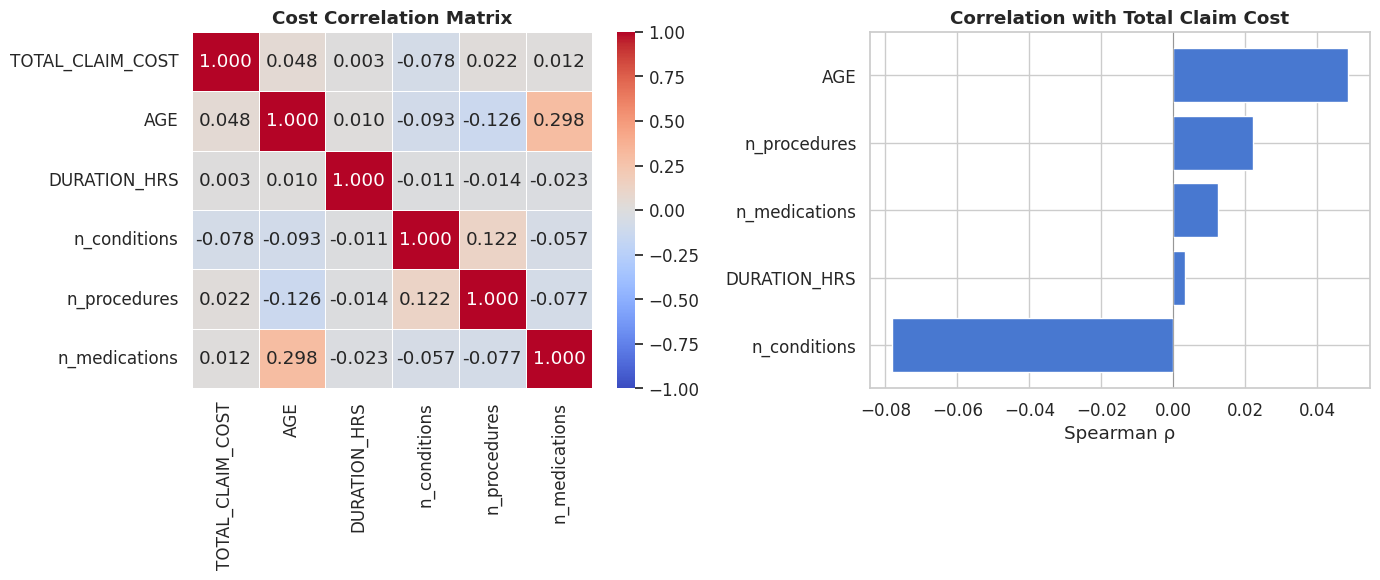

=== Spearman Correlations with Total Claim Cost ===
  AGE                  ρ= 0.0490  p=8.93e-30  *** Sig
  DURATION_HRS         ρ=-0.1555  p=4.62e-286  *** Sig
  n_conditions         ρ=-0.0923  p=3.64e-101  *** Sig
  n_procedures         ρ= 0.0329  p=3.09e-14  *** Sig
  n_medications        ρ=-0.0013  p=7.70e-01  


In [6]:
# 4.1 Cost drivers — correlation matrix
# Build encounter-level feature set
enc_features = encounters.copy()
enc_features = enc_features.merge(patients[['Id', 'AGE', 'GENDER', 'RACE']],
                                   left_on='PATIENT', right_on='Id', suffixes=('', '_pt'))

# Count conditions and procedures per encounter
cond_cnt = conditions.groupby('ENCOUNTER').size().reset_index(name='n_conditions')
proc_cnt = procedures.groupby('ENCOUNTER').size().reset_index(name='n_procedures')
med_cnt = medications.groupby('ENCOUNTER').size().reset_index(name='n_medications')

enc_features = enc_features.merge(cond_cnt, left_on='Id', right_on='ENCOUNTER', how='left')
enc_features = enc_features.merge(proc_cnt, left_on='Id', right_on='ENCOUNTER', how='left', suffixes=('', '_p'))
enc_features = enc_features.merge(med_cnt, left_on='Id', right_on='ENCOUNTER', how='left', suffixes=('', '_m'))
enc_features[['n_conditions', 'n_procedures', 'n_medications']] = enc_features[['n_conditions', 'n_procedures', 'n_medications']].fillna(0)

# Correlation analysis
numeric_cols = ['TOTAL_CLAIM_COST', 'AGE', 'DURATION_HRS', 'n_conditions', 'n_procedures', 'n_medications']
corr_matrix = enc_features[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0],
            center=0, linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Cost Correlation Matrix')

# Bar chart of correlations with cost
cost_corr = corr_matrix['TOTAL_CLAIM_COST'].drop('TOTAL_CLAIM_COST').sort_values()
bars = axes[1].barh(cost_corr.index, cost_corr.values,
                     color=[HIGHLIGHT if v > 0.1 else COLORS[0] for v in cost_corr.values], edgecolor='white')
axes[1].set_title('Correlation with Total Claim Cost')
axes[1].set_xlabel('Spearman ρ')
axes[1].axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('images/48_cost_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

# Spearman correlations with p-values
print("=== Spearman Correlations with Total Claim Cost ===")
for col in ['AGE', 'DURATION_HRS', 'n_conditions', 'n_procedures', 'n_medications']:
    r, p = spearmanr(enc_features[col].dropna(), enc_features.loc[enc_features[col].notna(), 'TOTAL_CLAIM_COST'])
    print(f"  {col:<20} ρ={r:>7.4f}  p={p:.2e}  {'*** Sig' if p < 0.05 else ''}")


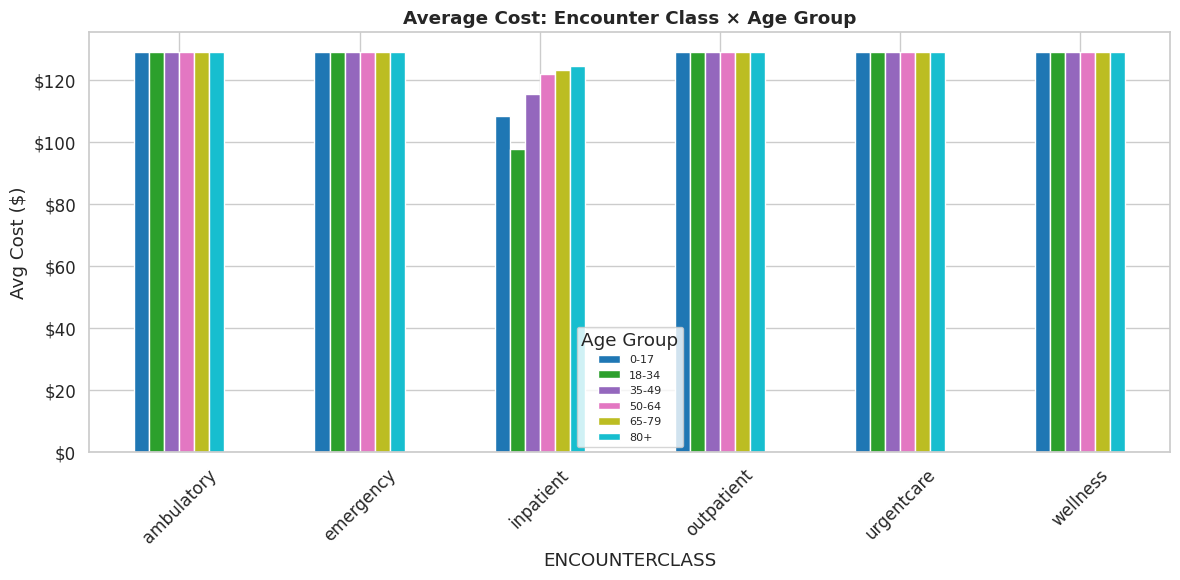

In [7]:
# 4.2 Cost by encounter class × age group
cost_class_age = enc_features.groupby(['ENCOUNTERCLASS', pd.cut(enc_features['AGE'], bins=[0,18,35,50,65,80,120],
    labels=['0-17','18-34','35-49','50-64','65-79','80+'])])['TOTAL_CLAIM_COST'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
cost_class_age.plot(kind='bar', ax=ax, cmap='tab10', edgecolor='white')
ax.set_title('Average Cost: Encounter Class × Age Group')
ax.set_ylabel('Avg Cost ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group', fontsize=8)

plt.tight_layout()
plt.savefig('images/49_cost_class_age.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Medication Economics
Drug cost analysis, polypharmacy financial impact, and payer coverage for medications.


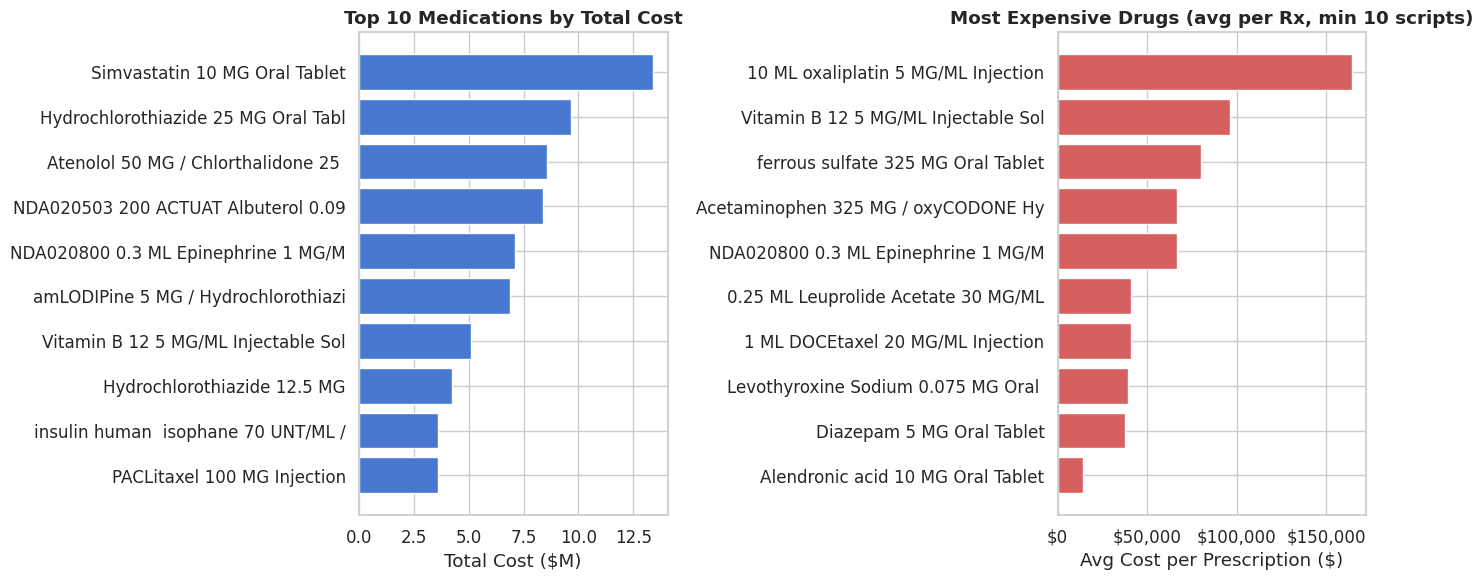

In [8]:
# 5.1 Top medications by total cost
med_costs = medications.groupby('DESCRIPTION').agg(
    prescriptions=('PATIENT', 'count'),
    unique_patients=('PATIENT', 'nunique'),
    total_cost=('TOTALCOST', 'sum'),
    avg_cost=('TOTALCOST', 'mean'),
    avg_base=('BASE_COST', 'mean'),
    avg_payer_covered=('PAYER_COVERAGE', 'mean')
).reset_index().sort_values('total_cost', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 by total cost
top_meds = med_costs.head(10)
axes[0].barh(top_meds['DESCRIPTION'].str[:35][::-1], top_meds['total_cost'][::-1] / 1e6,
              color=COLORS[0], edgecolor='white')
axes[0].set_title('Top 10 Medications by Total Cost')
axes[0].set_xlabel('Total Cost ($M)')

# Top 10 by avg cost per prescription
top_avg = med_costs[med_costs['prescriptions'] >= 10].nlargest(10, 'avg_cost')
axes[1].barh(top_avg['DESCRIPTION'].str[:35][::-1], top_avg['avg_cost'][::-1],
              color=COLORS[3], edgecolor='white')
axes[1].set_title('Most Expensive Drugs (avg per Rx, min 10 scripts)')
axes[1].set_xlabel('Avg Cost per Prescription ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('images/50_medication_costs.png', dpi=150, bbox_inches='tight')
plt.show()


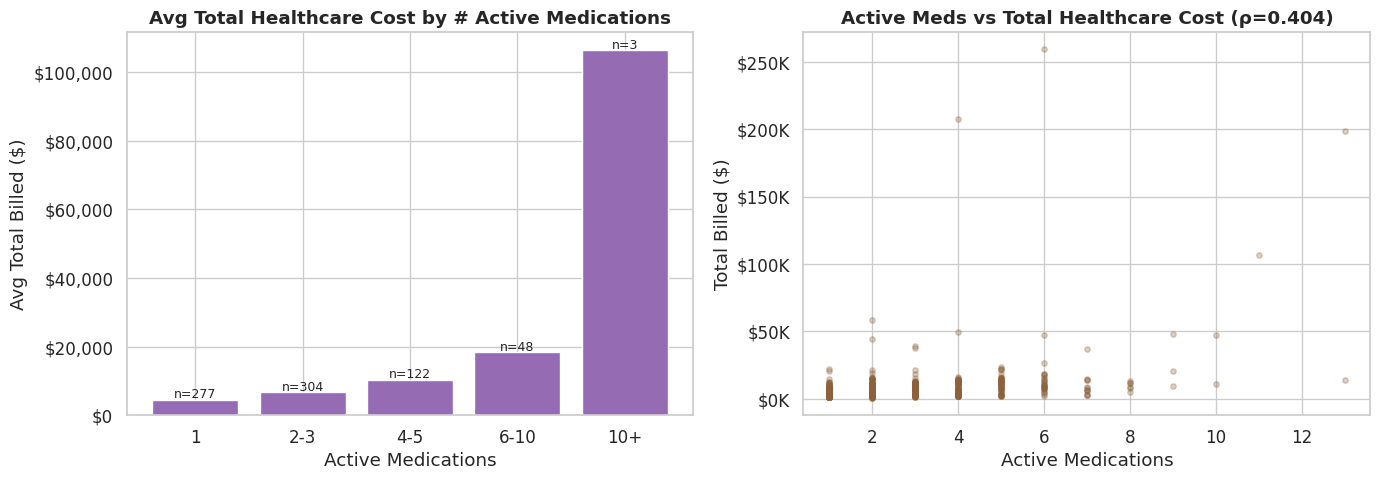

Polypharmacy-cost correlation: ρ=0.404, p=5.57e-31


In [9]:
# 5.2 Polypharmacy cost impact
active_meds = medications[medications['STOP'].isna()]
poly = active_meds.groupby('PATIENT').agg(
    active_meds=('DESCRIPTION', 'nunique'),
    monthly_cost=('TOTALCOST', 'sum')
).reset_index()
poly = poly.merge(patient_finance[['PATIENT', 'total_billed', 'AGE', 'AGE_GROUP']], on='PATIENT', how='left')
poly['poly_group'] = pd.cut(poly['active_meds'], bins=[0, 1, 3, 5, 10, 50],
                             labels=['1', '2-3', '4-5', '6-10', '10+'], right=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost by polypharmacy level
poly_cost = poly.groupby('poly_group')['total_billed'].agg(['mean', 'median', 'count'])
axes[0].bar(poly_cost.index.astype(str), poly_cost['mean'], color=COLORS[4], edgecolor='white')
axes[0].set_title('Avg Total Healthcare Cost by # Active Medications')
axes[0].set_xlabel('Active Medications')
axes[0].set_ylabel('Avg Total Billed ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (idx, row) in enumerate(poly_cost.iterrows()):
    axes[0].text(i, row['mean'] + 500, f'n={int(row["count"])}', ha='center', fontsize=9)

# Correlation
r, p = spearmanr(poly['active_meds'], poly['total_billed'].fillna(0))
axes[1].scatter(poly['active_meds'], poly['total_billed'], alpha=0.3, s=15, color=COLORS[5])
axes[1].set_title(f'Active Meds vs Total Healthcare Cost (ρ={r:.3f})')
axes[1].set_xlabel('Active Medications')
axes[1].set_ylabel('Total Billed ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('images/51_polypharmacy_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Polypharmacy-cost correlation: ρ={r:.3f}, p={p:.2e}")


---
## 6. Year-over-Year Financial Trends
Cost inflation, payer mix shifts, and spending projections.


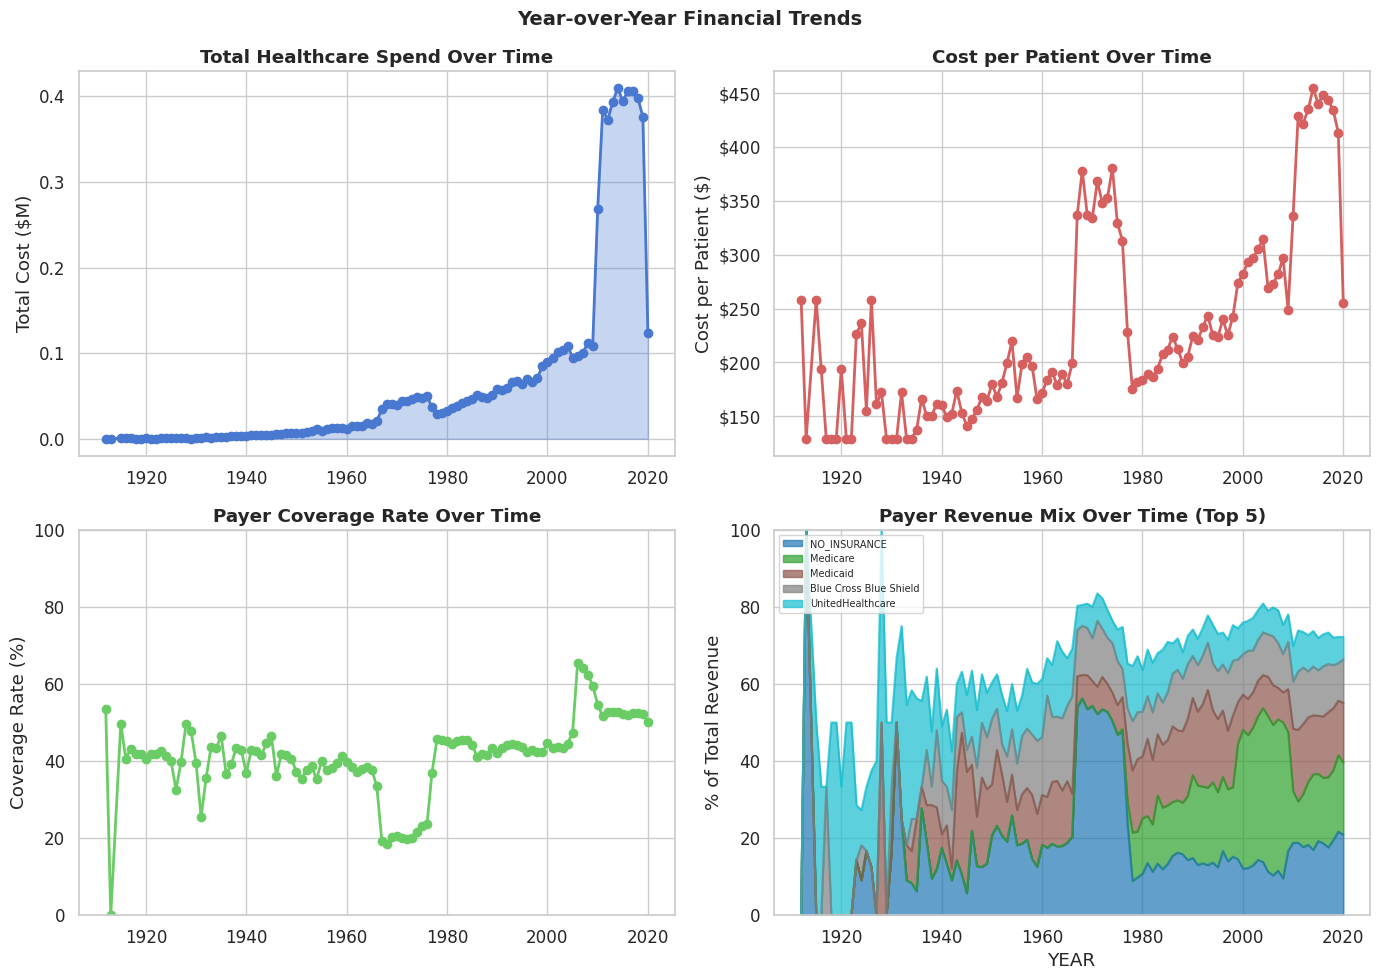

=== YoY Total Cost Change ===
  1913: ↓ 50.0% ($129)
  1915: ↑ 300.0% ($517)
  1916: ↓ 25.0% ($387)
  1917: ↓ 0.0% ($387)
  1918: ↓ 33.3% ($258)
  1919: ↓ 0.0% ($258)
  1920: ↑ 50.0% ($387)
  1921: ↓ 33.3% ($258)
  1922: ↓ 0.0% ($258)
  1923: ↑ 250.0% ($904)
  1924: ↑ 57.1% ($1,421)
  1925: ↓ 45.5% ($775)
  1926: ↑ 33.3% ($1,033)
  1927: ↓ 37.5% ($646)
  1928: ↓ 20.0% ($517)
  1929: ↓ 50.0% ($258)
  1930: ↑ 200.0% ($775)
  1931: ↓ 0.0% ($775)
  1932: ↑ 100.0% ($1,550)
  1933: ↓ 8.3% ($1,421)
  1934: ↑ 9.1% ($1,550)
  1935: ↑ 33.3% ($2,067)
  1936: ↑ 12.5% ($2,325)
  1937: ↑ 16.7% ($2,712)
  1938: ↓ 0.0% ($2,712)
  1939: ↑ 19.0% ($3,229)
  1940: ↑ 14.4% ($3,694)
  1941: ↑ 4.9% ($3,875)
  1942: ↑ 10.0% ($4,262)
  1943: ↑ 6.1% ($4,521)
  1944: ↑ 8.6% ($4,908)
  1945: ↓ 7.9% ($4,521)
  1946: ↑ 17.1% ($5,296)
  1947: ↑ 14.6% ($6,071)
  1948: ↑ 19.1% ($7,233)
  1949: ↓ 7.1% ($6,716)
  1950: ↑ 1.9% ($6,845)
  1951: ↑ 5.7% ($7,233)
  1952: ↑ 12.5% ($8,137)
  1953: ↑ 7.9% ($8,783)
  1954: ↑ 25.

In [10]:
# 6.1 YoY cost trends
enc_payer = encounters.merge(payers[['Id', 'NAME']], left_on='PAYER', right_on='Id', suffixes=('', '_pyr'))

yearly_finance = enc_payer.groupby('YEAR').agg(
    total_cost=('TOTAL_CLAIM_COST', 'sum'),
    avg_cost=('TOTAL_CLAIM_COST', 'mean'),
    median_cost=('TOTAL_CLAIM_COST', 'median'),
    total_covered=('PAYER_COVERAGE', 'sum'),
    total_oop=('OUT_OF_POCKET', 'sum'),
    encounters=('Id', 'count'),
    unique_patients=('PATIENT', 'nunique')
).reset_index()
yearly_finance['cost_per_patient'] = yearly_finance['total_cost'] / yearly_finance['unique_patients']
yearly_finance['coverage_rate'] = (yearly_finance['total_covered'] / yearly_finance['total_cost'] * 100)
yearly_finance['yoy_change'] = yearly_finance['total_cost'].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total spend trend
axes[0,0].fill_between(yearly_finance['YEAR'], yearly_finance['total_cost']/1e6, alpha=0.3, color=COLORS[0])
axes[0,0].plot(yearly_finance['YEAR'], yearly_finance['total_cost']/1e6, color=COLORS[0], marker='o', linewidth=2)
axes[0,0].set_title('Total Healthcare Spend Over Time')
axes[0,0].set_ylabel('Total Cost ($M)')

# Cost per patient trend
axes[0,1].plot(yearly_finance['YEAR'], yearly_finance['cost_per_patient'], color=COLORS[3], marker='o', linewidth=2)
axes[0,1].set_title('Cost per Patient Over Time')
axes[0,1].set_ylabel('Cost per Patient ($)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Coverage rate trend
axes[1,0].plot(yearly_finance['YEAR'], yearly_finance['coverage_rate'], color=COLORS[2], marker='o', linewidth=2)
axes[1,0].set_title('Payer Coverage Rate Over Time')
axes[1,0].set_ylabel('Coverage Rate (%)')
axes[1,0].set_ylim(0, 100)

# Payer mix over time
payer_yearly = enc_payer.groupby(['YEAR', 'NAME'])['TOTAL_CLAIM_COST'].sum().unstack(fill_value=0)
top_payers = enc_payer.groupby('NAME')['TOTAL_CLAIM_COST'].sum().nlargest(5).index
payer_yearly_pct = payer_yearly[top_payers].div(payer_yearly.sum(axis=1), axis=0) * 100
payer_yearly_pct.plot(kind='area', stacked=True, ax=axes[1,1], alpha=0.7, cmap='tab10')
axes[1,1].set_title('Payer Revenue Mix Over Time (Top 5)')
axes[1,1].set_ylabel('% of Total Revenue')
axes[1,1].legend(fontsize=7, loc='upper left')
axes[1,1].set_ylim(0, 100)

plt.suptitle('Year-over-Year Financial Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/52_yoy_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== YoY Total Cost Change ===")
for _, row in yearly_finance.dropna(subset=['yoy_change']).iterrows():
    direction = '↑' if row['yoy_change'] > 0 else '↓'
    print(f"  {int(row['YEAR'])}: {direction} {abs(row['yoy_change']):.1f}% (${row['total_cost']:,.0f})")


---
## 7. Uninsured Population Analysis


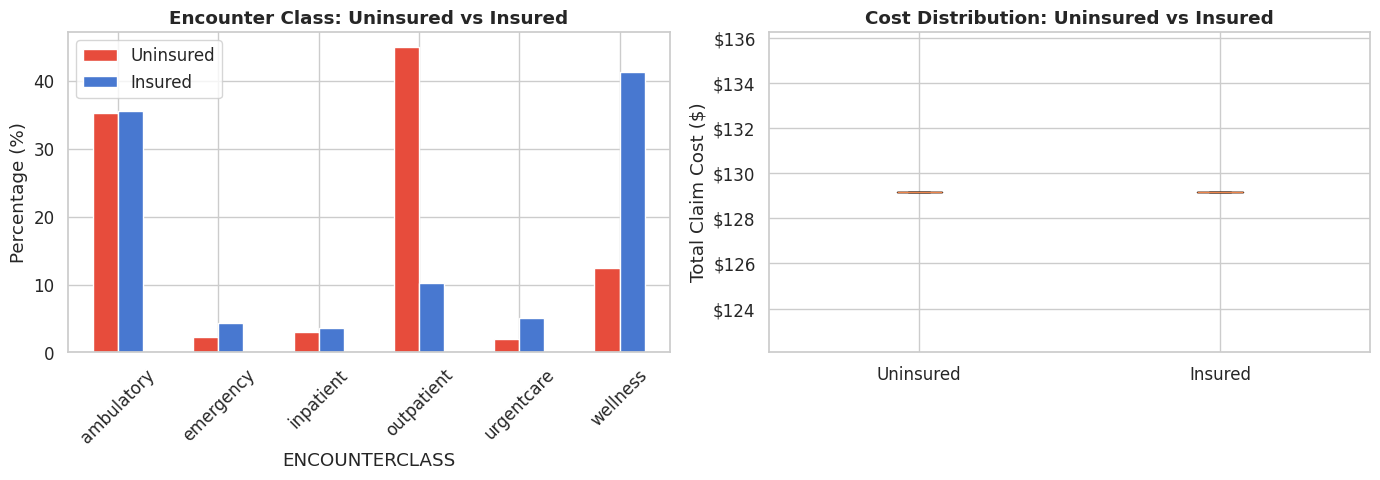

Uninsured encounters: 10,175 (19.1%)
Uninsured unique patients: 693
Cost comparison (Mann-Whitney): U=219,837,346, p=0.3399
  Uninsured median cost: $129.16
  Insured median cost:   $129.16


In [11]:
# 7.1 Uninsured encounters deep dive
enc_payer_named = encounters.merge(payers[['Id', 'NAME']], left_on='PAYER', right_on='Id', suffixes=('', '_pyr'))
uninsured = enc_payer_named[enc_payer_named['NAME'] == 'NO_INSURANCE']
insured = enc_payer_named[enc_payer_named['NAME'] != 'NO_INSURANCE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Encounter class comparison
ui_class = uninsured['ENCOUNTERCLASS'].value_counts(normalize=True) * 100
ins_class = insured['ENCOUNTERCLASS'].value_counts(normalize=True) * 100
compare = pd.DataFrame({'Uninsured': ui_class, 'Insured': ins_class}).fillna(0)
compare.plot(kind='bar', ax=axes[0], color=[HIGHLIGHT, COLORS[0]], edgecolor='white')
axes[0].set_title('Encounter Class: Uninsured vs Insured')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

# Cost comparison
axes[1].boxplot([uninsured['TOTAL_CLAIM_COST'], insured['TOTAL_CLAIM_COST']],
                labels=['Uninsured', 'Insured'], showfliers=False)
axes[1].set_title('Cost Distribution: Uninsured vs Insured')
axes[1].set_ylabel('Total Claim Cost ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('images/53_uninsured_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

u_stat, p = mannwhitneyu(uninsured['TOTAL_CLAIM_COST'], insured['TOTAL_CLAIM_COST'])
print(f"Uninsured encounters: {len(uninsured):,} ({len(uninsured)/len(encounters)*100:.1f}%)")
print(f"Uninsured unique patients: {uninsured['PATIENT'].nunique()}")
print(f"Cost comparison (Mann-Whitney): U={u_stat:,.0f}, p={p:.4f}")
print(f"  Uninsured median cost: ${uninsured['TOTAL_CLAIM_COST'].median():,.2f}")
print(f"  Insured median cost:   ${insured['TOTAL_CLAIM_COST'].median():,.2f}")


---
## 8. Power BI-Ready Exports


In [12]:
# Export financial summary tables
yearly_finance.to_csv('data/processed/financial_yearly_trends.csv', index=False)
payer_detail.to_csv('data/processed/payer_performance_detail.csv', index=False)
patient_finance.to_csv('data/processed/patient_financial_summary.csv', index=False)
med_costs.head(50).to_csv('data/processed/top_medication_costs.csv', index=False)

print(f"Exported:")
print(f"  financial_yearly_trends.csv     ({len(yearly_finance)} rows)")
print(f"  payer_performance_detail.csv    ({len(payer_detail)} rows)")
print(f"  patient_financial_summary.csv   ({len(patient_finance)} rows)")
print(f"  top_medication_costs.csv        (50 rows)")


Exported:
  financial_yearly_trends.csv     (108 rows)
  payer_performance_detail.csv    (10 rows)
  patient_financial_summary.csv   (1171 rows)
  top_medication_costs.csv        (50 rows)


---
*Notebook 05 complete. Cost distributions, payer analysis, financial burden, cost drivers, medication economics, YoY trends, and uninsured analysis delivered.*
